# ====================================================

##Install

In [ ]:
!pip install -q transformers accelerate timm sentencepiece safetensors
!pip install -q opencv-python pillow matplotlib numpy scipy

##Imports + memory helpers

In [ ]:
import os
import gc
import json
from pathlib import Path

import cv2
import torch
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

from transformers import AutoImageProcessor, AutoModelForSemanticSegmentation

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("DEVICE:", DEVICE)

def clear_memory():
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.ipc_collect()

def show_imgs(imgs, titles=None, figsize=(16, 6)):
    plt.figure(figsize=figsize)
    for i, img in enumerate(imgs):
        plt.subplot(1, len(imgs), i + 1)
        if isinstance(img, Image.Image):
            img = np.array(img)
        if img.ndim == 2:
            plt.imshow(img, cmap="gray")
        else:
            plt.imshow(img)
        plt.axis("off")
        if titles:
            plt.title(titles[i])
    plt.show()

def save_rgb(img, path):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    img.save(path)

def save_mask(mask, path):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)

    if isinstance(mask, Image.Image):
        mask = mask.convert("L")
        mask.save(path)
        return

    mask = np.array(mask)
    if mask.dtype == bool:
        mask = mask.astype(np.uint8) * 255
    elif mask.max() <= 1:
        mask = mask.astype(np.uint8) * 255
    else:
        mask = mask.astype(np.uint8)

    Image.fromarray(mask).save(path)

def resize_rgb(img, size=(768, 1024)):
    return img.resize(size, Image.BICUBIC)

# def resize_mask(mask, size=(768, 1024)):
#     if isinstance(mask, np.ndarray):
#         mask = Image.fromarray(mask.astype(np.uint8))
#     return mask.resize(size, Image.NEAREST)

# def pil_to_np(img):
#     return np.array(img)

# def np_to_pil(arr):
#     return Image.fromarray(arr.astype(np.uint8))

DEVICE: cpu


## Helper fuctions

In [ ]:
def clean_mask(mask, open_k=5, close_k=7, blur_k=0):
    mask = mask.astype(np.uint8)

    kernel_open = np.ones((open_k, open_k), np.uint8)
    kernel_close = np.ones((close_k, close_k), np.uint8)

    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel_open)
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel_close)

    if blur_k and blur_k > 1:
        if blur_k % 2 == 0:
            blur_k += 1
        mask = cv2.GaussianBlur(mask, (blur_k, blur_k), 0)

    mask = (mask > 127).astype(np.uint8) * 255
    return mask

def get_binary_mask_from_labels(label_map, target_labels):
    mask = np.isin(label_map, target_labels).astype(np.uint8) * 255
    return mask

def pick_best_top_labels(label_map, candidate_label_sets, min_area_ratio=0.01, max_area_ratio=0.55):
    """
    Chọn bộ label hợp lý hơn dựa trên diện tích mask.
    Không hoàn hảo, nhưng đỡ hard-code cứng [4].
    """
    H, W = label_map.shape
    total_area = H * W

    best_labels = None
    best_mask = None
    best_score = -1

    for labels in candidate_label_sets:
        mask = get_binary_mask_from_labels(label_map, labels)
        mask = clean_mask(mask, open_k=3, close_k=7)
        area_ratio = (mask > 127).sum() / total_area

        # bỏ các mask quá nhỏ hoặc quá lớn
        if area_ratio < min_area_ratio or area_ratio > max_area_ratio:
            continue

        # score đơn giản: ưu tiên mask đủ lớn nhưng không nuốt cả người
        score = area_ratio
        if score > best_score:
            best_score = score
            best_labels = labels
            best_mask = mask

    if best_labels is None:
        # fallback cứng nếu không tìm được bộ nào hợp lý
        best_labels = [4]
        best_mask = get_binary_mask_from_labels(label_map, best_labels)

    return best_labels, best_mask

def keep_largest_component(mask):
    mask_bin = (mask > 127).astype(np.uint8)
    num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(mask_bin, connectivity=8)

    if num_labels <= 1:
        return (mask_bin * 255).astype(np.uint8)

    largest_idx = 1 + np.argmax(stats[1:, cv2.CC_STAT_AREA])
    largest = (labels == largest_idx).astype(np.uint8) * 255
    return largest

def refine_top_mask(top_mask, open_k=5, close_k=9):
    top_mask = clean_mask(top_mask, open_k=open_k, close_k=close_k)
    top_mask = keep_largest_component(top_mask)
    top_mask = clean_mask(top_mask, open_k=3, close_k=7)
    return top_mask

def create_robust_agnostic(person_img_pil, parsing_map, top_labels=[4], object_mask=None):
    """
    Tạo agnostic image và mask CHUẨN VTON.
    Bao gồm cả việc xóa da cổ, tay để tạo không gian cho áo mới.
    """
    person_np = np.array(person_img_pil)

    # 1. Lấy mask áo ban đầu
    mask_cloth = np.isin(parsing_map, top_labels).astype(np.uint8) * 255

    # 2. Gộp mask túi (nếu có)
    if object_mask is not None:
        mask_object = (object_mask > 127).astype(np.uint8) * 255
        mask_cloth = np.maximum(mask_cloth, mask_object)

    # 3. Lấy mask cổ và cánh tay (Label 14: tay phải, 15: tay trái - tuỳ thuộc vào Segformer model)
    # LƯU Ý: Segformer mattmdjaga/segformer_b2_clothes quy định:
    # 14 = right-arm, 15 = left-arm
    skin_labels = [14, 15]
    mask_skin = np.isin(parsing_map, skin_labels).astype(np.uint8) * 255

    # 4. TẠO AGNOSTIC MASK CHUẨN: Gộp áo + da thịt + làm phình (Dilate)
    combined_mask = np.maximum(mask_cloth, mask_skin)

    # Dilate mask để che phủ cả những đường viền, nếp gấp lồi ra ngoài
    kernel = np.ones((15, 15), np.uint8)
    agnostic_mask_np = cv2.dilate(combined_mask, kernel, iterations=2)

    # 5. TẠO AGNOSTIC IMAGE CHUẨN:
    # Những chỗ mask=255 (trắng), tô màu xám trung tính (127) TUYỆT ĐỐI
    agnostic_np = person_np.copy()
    agnostic_np[agnostic_mask_np > 127] = 127

    return Image.fromarray(agnostic_np), Image.fromarray(agnostic_mask_np)

##Folder config

In [ ]:
ROOT = Path("/content/offline_assets")
PERSONS_DIR = ROOT / "persons"
CLOTHES_DIR = ROOT / "clothes"
PREPROCESS_DIR = ROOT / "preprocess"
CLOTH_MASK_DIR = ROOT / "cloth_masks"

for p in [PERSONS_DIR, CLOTHES_DIR, PREPROCESS_DIR, CLOTH_MASK_DIR]:
    p.mkdir(parents=True, exist_ok=True)

PERSON_ID = "p001"
CLOTH_ID = "c001"

PERSON_PRE_DIR = PREPROCESS_DIR / PERSON_ID
PERSON_PRE_DIR.mkdir(parents=True, exist_ok=True)

IMG_SIZE = (768, 1024)

##Upload person + cloth

Upload PERSON image:


Saving person.png to person.png
Upload CLOTH image:


Saving cloth.png to cloth.png


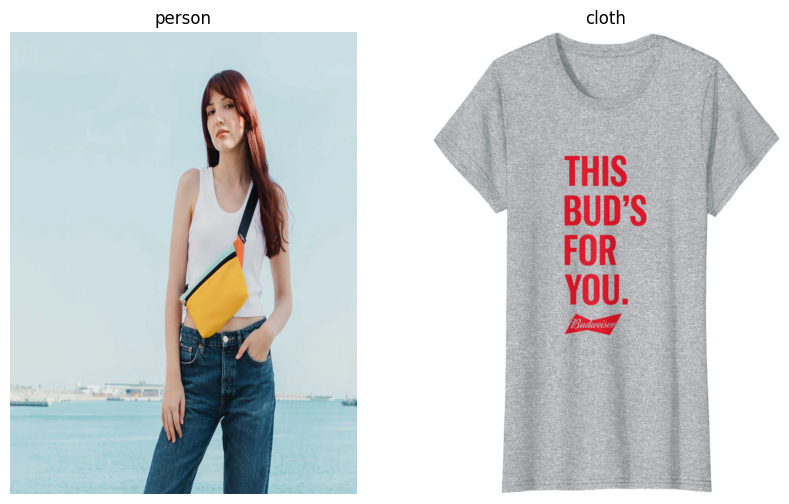

In [ ]:
from google.colab import files

print("Upload PERSON image:")
uploaded_person = files.upload()
person_path = list(uploaded_person.keys())[0]

print("Upload CLOTH image:")
uploaded_cloth = files.upload()
cloth_path = list(uploaded_cloth.keys())[0]

person_img = resize_rgb(Image.open(person_path).convert("RGB"), IMG_SIZE)
cloth_img = resize_rgb(Image.open(cloth_path).convert("RGB"), IMG_SIZE)

save_rgb(person_img, PERSONS_DIR / f"{PERSON_ID}.jpg")
save_rgb(cloth_img, CLOTHES_DIR / f"{CLOTH_ID}.jpg")

show_imgs([person_img, cloth_img], ["person", "cloth"], figsize=(10, 6))

#Stage C - Grounding DINO + SAM

##Cài lib

In [ ]:
!pip install -q git+https://github.com/facebookresearch/segment-anything.git
!pip install -q opencv-python pillow matplotlib numpy

  Preparing metadata (setup.py) ... done


In [ ]:
!wget -q https://dl.fbaipublicfiles.com/segment_anything/sam_vit_h_4b8939.pth

##Load Grounding DINO

In [ ]:
from transformers import AutoProcessor, AutoModelForZeroShotObjectDetection

model_id = "IDEA-Research/grounding-dino-tiny"

processor = AutoProcessor.from_pretrained(model_id)
model = AutoModelForZeroShotObjectDetection.from_pretrained(model_id).to(DEVICE)

text_prompt = "bag."
inputs = processor(images=person_img, text=text_prompt, return_tensors="pt").to(DEVICE)

with torch.no_grad():
    outputs = model(**inputs)

results = processor.post_process_grounded_object_detection(
    outputs,
    inputs.input_ids,
    threshold=0.3,
    target_sizes=[person_img.size[::-1]]  # (H, W)
)

result = results[0]
boxes = result["boxes"].cpu().numpy()
scores = result["scores"].cpu().numpy()
labels = result["labels"]

print("Detected labels:", labels)
print("Boxes:", boxes)
print("Scores:", scores)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/457 [00:00<?, ?B/s]

The image processor of type `GroundingDinoImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/689M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/990 [00:00<?, ?it/s]

Detected labels: ['bag', 'bag']
Boxes: [[372.5054  480.32434 530.14404 680.64014]
 [372.29755 319.53732 553.0144  680.3673 ]]
Scores: [0.43505037 0.43872344]


/usr/local/lib/python3.12/dist-packages/transformers/models/grounding_dino/processing_grounding_dino.py:91: FutureWarning: The key `labels` is will return integer ids in `GroundingDinoProcessor.post_process_grounded_object_detection` output since v4.51.0. Use `text_labels` instead to retrieve string object names.
  warnings.warn(self.message, FutureWarning)


##Detect object

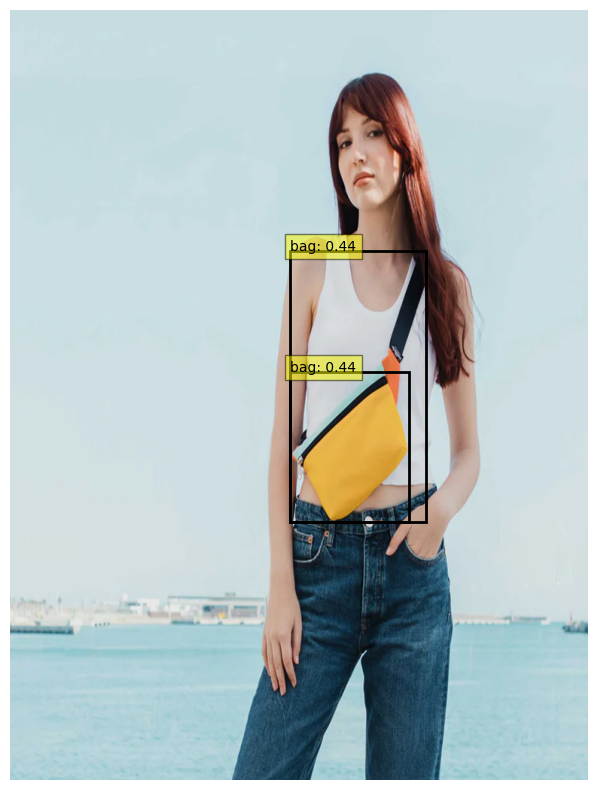

In [ ]:
import matplotlib.patches as patches

fig, ax = plt.subplots(1, figsize=(8, 10))
ax.imshow(person_img)

for box, score, label in zip(boxes, scores, labels):
    x1, y1, x2, y2 = box
    rect = patches.Rectangle((x1, y1), x2-x1, y2-y1, fill=False, linewidth=2)
    ax.add_patch(rect)
    ax.text(x1, y1, f"{label}: {score:.2f}", fontsize=10, bbox=dict(facecolor="yellow", alpha=0.5))

ax.axis("off")
plt.show()

##Load SAM + segment

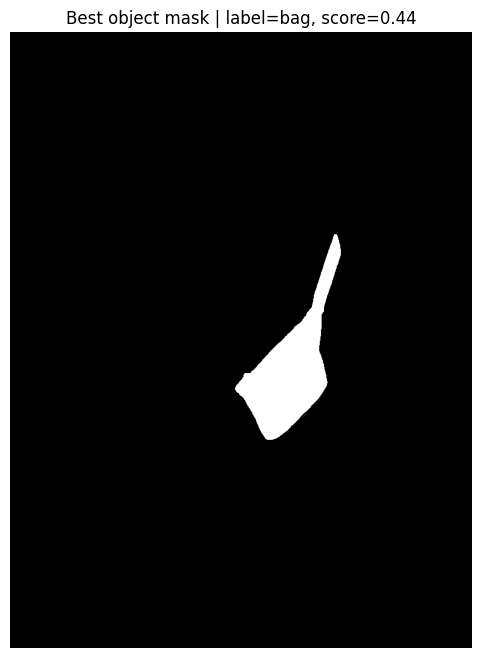

In [ ]:
from segment_anything import sam_model_registry, SamPredictor

sam = sam_model_registry["vit_h"](checkpoint="sam_vit_h_4b8939.pth")
sam.to(DEVICE)

predictor = SamPredictor(sam)
predictor.set_image(np.array(person_img))

def clean_object_mask(mask, open_k=3, close_k=7):
    mask = (mask > 0).astype(np.uint8) * 255
    mask = clean_mask(mask, open_k=open_k, close_k=close_k)
    mask = keep_largest_component(mask)
    return mask

object_mask = None
best_label = None
best_score = None

TARGET_OBJECT_LABEL = "bag"

if len(boxes) == 0:
    print("Không detect được object.")
else:
    matched_indices = []
    for i, label in enumerate(labels):
        if TARGET_OBJECT_LABEL.lower() in str(label).lower():
            matched_indices.append(i)

    if len(matched_indices) == 0:
        print(f"Không có object nào match label '{TARGET_OBJECT_LABEL}'.")
    else:
        best_idx = matched_indices[int(np.argmax([scores[i] for i in matched_indices]))]
        best_box = boxes[best_idx]
        best_label = labels[best_idx]
        best_score = float(scores[best_idx])

        masks_pred, scores_pred, _ = predictor.predict(
            box=best_box,
            multimask_output=False
        )

        object_mask = masks_pred[0].astype(np.uint8)
        object_mask = clean_object_mask(object_mask, open_k=3, close_k=7)

        plt.figure(figsize=(6, 8))
        plt.imshow(object_mask, cmap="gray")
        plt.axis("off")
        plt.title(f"Best object mask | label={best_label}, score={best_score:.2f}")
        plt.show()

##Save output

In [ ]:
OBJECT_LABEL = TARGET_OBJECT_LABEL
object_mask_path = PERSON_PRE_DIR / f"object_mask_{OBJECT_LABEL}.png"

if object_mask is not None:
    save_mask(object_mask, object_mask_path)
    print("Saved:", object_mask_path)
else:
    print(f"No object mask saved for label: {OBJECT_LABEL}")

Saved: /content/offline_assets/preprocess/p001/object_mask_bag.png


In [ ]:
del model
del processor
del sam
del predictor
clear_memory()

#Stage A — Human parsing → agnostic + agnostic_mask

##Load parsing model

In [ ]:
PARSING_MODEL_ID = "mattmdjaga/segformer_b2_clothes"

processor = AutoImageProcessor.from_pretrained(PARSING_MODEL_ID)
parsing_model = AutoModelForSemanticSegmentation.from_pretrained(PARSING_MODEL_ID).to(DEVICE)
parsing_model.eval()

print("Parsing model loaded.")

preprocessor_config.json:   0%|          | 0.00/271 [00:00<?, ?B/s]

The image processor of type `SegformerImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/109M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/380 [00:00<?, ?it/s]

Parsing model loaded.


##Run parsing

In [ ]:
@torch.no_grad()
def run_segformer_parsing(image_pil, processor, model, device=DEVICE):
    inputs = processor(images=image_pil, return_tensors="pt").to(device)
    outputs = model(**inputs)
    logits = outputs.logits  # [B, C, h, w]

    upsampled = torch.nn.functional.interpolate(
        logits,
        size=image_pil.size[::-1],   # (H, W)
        mode="bilinear",
        align_corners=False
    )
    pred = upsampled.argmax(dim=1)[0].detach().cpu().numpy().astype(np.uint8)
    return pred

person_parsing_map = run_segformer_parsing(person_img, processor, parsing_model)

print("person parsing labels:", np.unique(person_parsing_map))

person parsing labels: [ 0  2  4  6  8 11 14 15 16]


##Helper chọn label áo

TOP_LABELS selected for person: [4]
TOP_LABELS selected for person: [4]


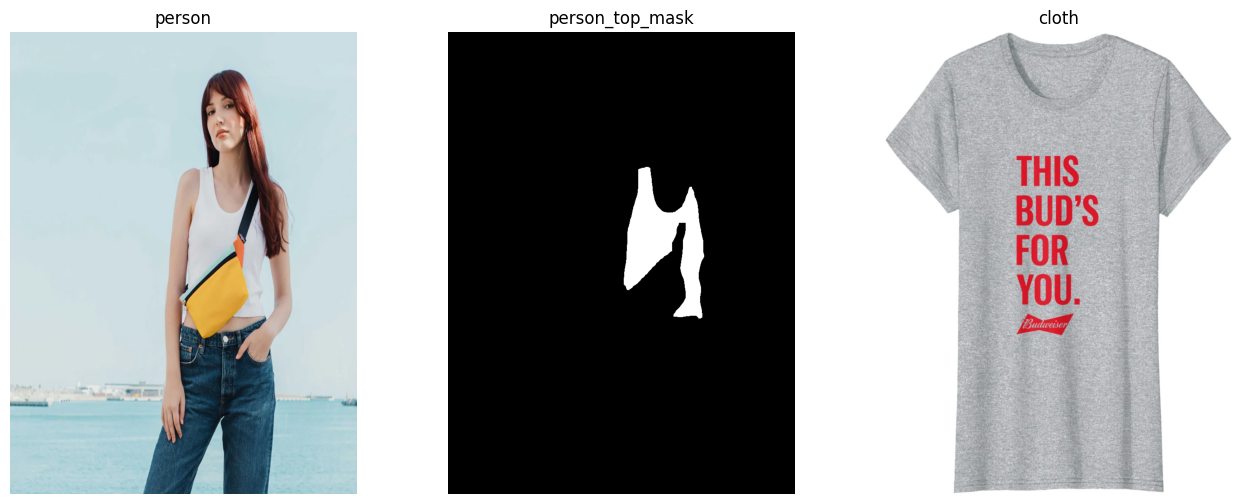

In [ ]:
TOP_LABELS = [4]

person_top_mask = get_binary_mask_from_labels(person_parsing_map, TOP_LABELS)
person_top_mask = clean_mask(person_top_mask, open_k=5, close_k=15)
person_top_mask = keep_largest_component(person_top_mask)

print("TOP_LABELS selected for person:", TOP_LABELS)

print("TOP_LABELS selected for person:", TOP_LABELS)

show_imgs(
    [person_img, person_top_mask, cloth_img],
    ["person", "person_top_mask", "cloth"],
    figsize=(16, 6)
)

##Xem parsing map

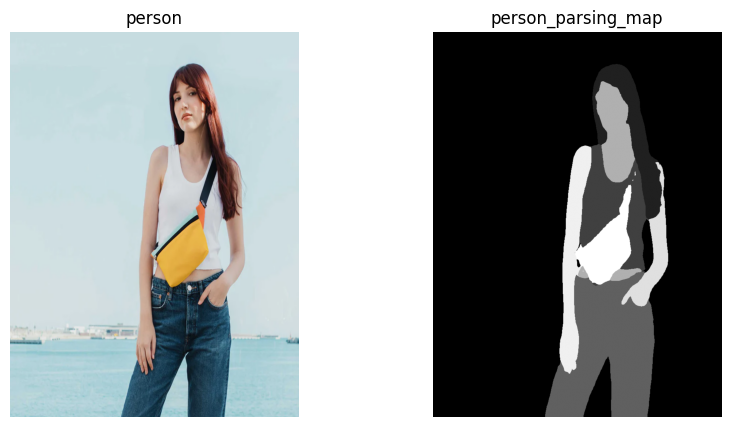

In [ ]:
show_imgs(
    [person_img, person_parsing_map],
    ["person", "person_parsing_map"],
    figsize=(10, 5)
)

##Morphology làm sạch mask

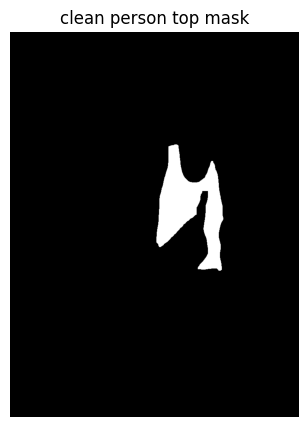

In [ ]:
person_top_mask = clean_mask(person_top_mask, open_k=5, close_k=9)

show_imgs(
    [person_top_mask],
    ["clean person top mask"],
    figsize=(10, 5)
)

##Tạo agnostic.png và agnostic_mask.png

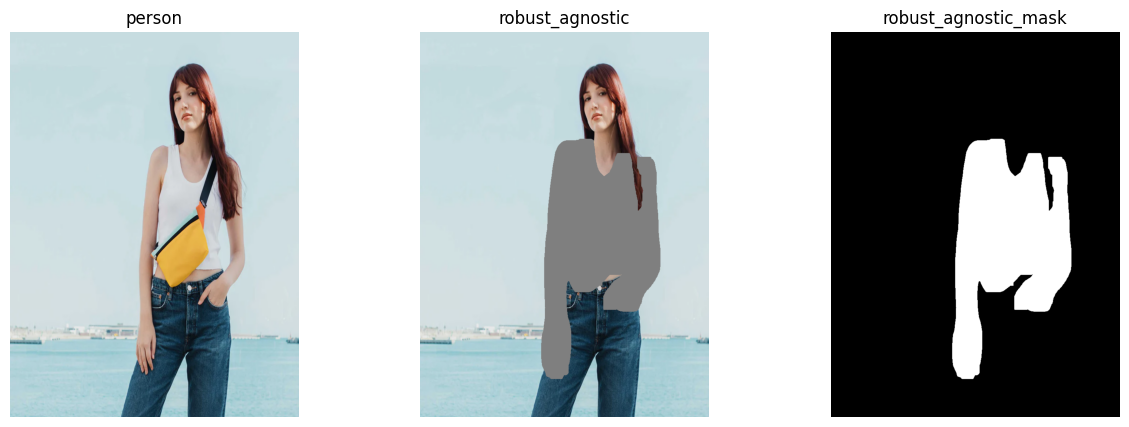

In [ ]:
# refine lại person_top_mask trước khi tạo agnostic

if 'object_mask' in globals() and object_mask is not None:
    object_mask_resized = cv2.resize(
        object_mask,
        (person_top_mask.shape[1], person_top_mask.shape[0]),
        interpolation=cv2.INTER_NEAREST
    )

    # MẸO Ở ĐÂY: Làm phình RIÊNG mask túi ra vài pixel
    # Khi dán lên áo, phần phình ra này sẽ "ăn" mất cái rãnh viền, tạo thành 1 khối đặc
    kernel = np.ones((11, 11), np.uint8)
    object_mask_dilated = cv2.dilate(object_mask_resized, kernel, iterations=1)

    # Gộp mask áo và mask túi đã phình to thành 1 khối trắng
    person_top_mask = np.maximum(person_top_mask, object_mask_dilated)

    # Đóng lại các lỗ hổng nhỏ xíu nếu còn
    person_top_mask = clean_mask(person_top_mask, open_k=0, close_k=15)

agnostic_img, agnostic_mask = create_robust_agnostic(
    person_img,
    person_parsing_map,
    top_labels=TOP_LABELS,
    object_mask=object_mask if 'object_mask' in globals() else None
)

save_rgb(agnostic_img, PERSON_PRE_DIR / "agnostic.png")
save_mask(agnostic_mask, PERSON_PRE_DIR / "agnostic_mask.png")

show_imgs(
    [person_img, agnostic_img, agnostic_mask],
    ["person", "robust_agnostic", "robust_agnostic_mask"],
    figsize=(15, 5)
)

##Save parsing map rồi clear memory Stage A

In [ ]:
save_mask(person_parsing_map, PERSON_PRE_DIR / "person_parsing_map.png")

del parsing_model
del processor
clear_memory()

print("Stage A done.")
print("Saved:")
print(PERSON_PRE_DIR / "agnostic.png")
print(PERSON_PRE_DIR / "agnostic_mask.png")
print(PERSON_PRE_DIR / "person_parsing_map.png")

Stage A done.
Saved:
/content/offline_assets/preprocess/p001/agnostic.png
/content/offline_assets/preprocess/p001/agnostic_mask.png
/content/offline_assets/preprocess/p001/person_parsing_map.png


#DensePose

In [ ]:
!python -m pip install -q 'git+https://github.com/facebookresearch/detectron2.git'
!git clone -q https://github.com/facebookresearch/detectron2 /content/detectron2_repo
!wget -q https://dl.fbaipublicfiles.com/densepose/densepose_rcnn_R_50_FPN_s1x/165712039/model_final_162be9.pkl -O /content/densepose_model.pkl

  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 2.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.9/91.9 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.5/154.5 kB 8.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 32.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.3/57.3 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 269.8/269.8 kB 11.9 MB/s eta 0:00:00


In [ ]:
!pip install av
!pip install lap

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.3/36.3 MB 15.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 24.5 MB/s eta 0:00:00


In [ ]:
import cv2
import numpy as np
import torch
from pathlib import Path
from PIL import Image

import sys
sys.path.append("/content/detectron2_repo/projects/DensePose")

from detectron2.config import get_cfg
from detectron2.engine import DefaultPredictor
from densepose import add_densepose_config
from densepose.vis.extractor import DensePoseResultExtractor

DENSEPOSE_CFG = "/content/detectron2_repo/projects/DensePose/configs/densepose_rcnn_R_50_FPN_s1x.yaml"
DENSEPOSE_WEIGHTS = "/content/densepose_model.pkl"

def get_clean_densepose_with_debug(img_path, output_path, cfg_path, weights_path):
    output_path = Path(output_path)
    output_path.parent.mkdir(parents=True, exist_ok=True)

    print("[DEBUG 1] Đang khởi tạo mô hình...")
    cfg = get_cfg()
    add_densepose_config(cfg)
    cfg.merge_from_file(cfg_path)
    cfg.MODEL.WEIGHTS = weights_path
    cfg.MODEL.DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

    predictor = DefaultPredictor(cfg)

    print(f"[DEBUG 2] Đang đọc ảnh: {img_path}")
    img_cv2 = cv2.imread(str(img_path))
    if img_cv2 is None:
        raise ValueError("Không đọc được ảnh gốc, hãy check lại đường dẫn!")

    print("[DEBUG 3] Đang chạy inference dự đoán...")
    with torch.no_grad():
        outputs = predictor(img_cv2)

    if "instances" not in outputs or len(outputs["instances"]) == 0:
        raise RuntimeError("Không tìm thấy dáng người trong ảnh!")

    instances = outputs["instances"].to("cpu")
    print(f"[DEBUG 4] Đã tìm thấy {len(instances)} người. Kiểm tra các trường dữ liệu:")
    print(" -> Các trường có sẵn:", list(instances.get_fields().keys()))

    if not instances.has("pred_densepose"):
        raise RuntimeError("Model CÓ NHẬN RA NGƯỜI, nhưng KHÔNG TRẢ VỀ DENSEPOSE (Thiếu pred_densepose). Check lại file config/weights!")

    # Trích xuất dữ liệu
    extractor = DensePoseResultExtractor()
    densepose_data = extractor(instances)
    results, boxes_xywh = densepose_data

    # TẠO NỀN ĐEN
    black_bg = np.zeros_like(img_cv2)

    print("[DEBUG 5] Bắt đầu tự vẽ DensePose (Manual Render) thay vì dùng Visualizer mặc định...")
    drawn_count = 0
    for i, result in enumerate(results):
        box = boxes_xywh[i]
        x, y, w, h = [int(v) for v in box]

        # result.labels là ma trận chứa ID các bộ phận cơ thể (0-24)
        labels = result.labels.cpu().numpy()

        # Normalize (1-24) lên thang (0-255) để áp màu
        labels_norm = (labels * 255.0 / 24).astype(np.uint8)

        # Áp bảng màu PARULA (Chuẩn của DensePose)
        color_map = cv2.applyColorMap(labels_norm, cv2.COLORMAP_PARULA)

        # Chỉ lấy màu ở những vùng có cơ thể (labels > 0)
        mask = (labels > 0)[:, :, None].astype(np.uint8)

        # Tính toán tọa độ an toàn để không bị tràn ra ngoài viền ảnh
        img_h, img_w = black_bg.shape[:2]
        x1, y1 = max(0, x), max(0, y)
        x2, y2 = min(img_w, x + w), min(img_h, y + h)

        # Cắt chính xác phần color_map và mask khớp với tọa độ thật
        slice_h, slice_w = y2 - y1, x2 - x1
        color_map_sliced = color_map[:slice_h, :slice_w]
        mask_sliced = mask[:slice_h, :slice_w]

        # Dán đè lên nền đen (Mask == 1 thì lấy color, Mask == 0 thì giữ màu đen)
        roi = black_bg[y1:y2, x1:x2]
        black_bg[y1:y2, x1:x2] = roi * (1 - mask_sliced) + color_map_sliced * mask_sliced
        drawn_count += 1

    print(f"[DEBUG 6] Đã vẽ thành công {drawn_count} bộ DensePose.")
    print(f" -> Max pixel value (Nếu > 0 là chắc chắn có màu): {np.max(black_bg)}")

    cv2.imwrite(str(output_path), black_bg)
    return output_path

# Gọi hàm chạy
densepose_path = PERSON_PRE_DIR / "densepose.png"
print("============= BẮT ĐẦU CHẠY =============")

get_clean_densepose_with_debug(
    PERSONS_DIR / f"{PERSON_ID}.jpg",
    densepose_path,
    DENSEPOSE_CFG,
    DENSEPOSE_WEIGHTS
)

print("Đã lưu DensePose chuẩn VTON tại:", densepose_path)

# Show kết quả
show_imgs(
    [
        Image.open(PERSONS_DIR / f"{PERSON_ID}.jpg").convert("RGB"),
        Image.open(densepose_path).convert("RGB")
    ],
    ["person", "densepose_clean"],
    figsize=(10, 5)
)

============= BẮT ĐẦU CHẠY =============
[DEBUG 1] Đang khởi tạo mô hình...
[DEBUG 2] Đang đọc ảnh: /content/offline_assets/persons/p001.jpg
[DEBUG 3] Đang chạy inference dự đoán...


/usr/local/lib/python3.12/dist-packages/torch/functional.py:505: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at /pytorch/aten/src/ATen/native/TensorShape.cpp:4381.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]
W0427 16:33:05.963000 31922 torch/fx/_symbolic_trace.py:53] is_fx_tracing will return true for both fx.symbolic_trace and torch.export. Please use is_fx_tracing_symbolic_tracing() for specifically fx.symbolic_trace or torch.compiler.is_compiling() for specifically torch.export/compile.


[DEBUG 4] Đã tìm thấy 1 người. Kiểm tra các trường dữ liệu:
 -> Các trường có sẵn: ['pred_boxes', 'scores', 'pred_classes', 'pred_densepose']
[DEBUG 5] Bắt đầu tự vẽ DensePose (Manual Render) thay vì dùng Visualizer mặc định...
[DEBUG 6] Đã vẽ thành công 1 bộ DensePose.
 -> Max pixel value (Nếu > 0 là chắc chắn có màu): 252
Đã lưu DensePose chuẩn VTON tại: /content/offline_assets/preprocess/p001/densepose.png


#Stage B — Cloth mask

##Reload segmentation model cho cloth mask

In [ ]:
processor = AutoImageProcessor.from_pretrained(PARSING_MODEL_ID)
cloth_model = AutoModelForSemanticSegmentation.from_pretrained(PARSING_MODEL_ID).to(DEVICE)
cloth_model.eval()

print("Cloth segmentation model loaded.")

Loading weights:   0%|          | 0/380 [00:00<?, ?it/s]

Cloth segmentation model loaded.


##Run cloth parsing lại

In [ ]:
cloth_parsing_map = run_segformer_parsing(cloth_img, processor, cloth_model)

CLOTH_LABEL_CANDIDATES = [
    TOP_LABELS,   # ưu tiên bộ đã chọn cho person
    [4],
    [5],
    [6],
    [7],
    [4, 5],
    [4, 6],
    [4, 7],
    [5, 6],
    [5, 7],
    [4, 5, 6],
]

cloth_labels_used, cloth_mask = pick_best_top_labels(
    cloth_parsing_map,
    CLOTH_LABEL_CANDIDATES,
    min_area_ratio=0.05,
    max_area_ratio=0.90
)

cloth_mask = refine_top_mask(cloth_mask, open_k=5, close_k=9)

print("TOP_LABELS selected for cloth:", cloth_labels_used)

save_mask(cloth_mask, CLOTH_MASK_DIR / f"{CLOTH_ID}.png")
save_mask(cloth_parsing_map, CLOTH_MASK_DIR / f"{CLOTH_ID}_parsing_map.png")

show_imgs(
    [cloth_img, cloth_parsing_map, cloth_mask],
    ["cloth", "cloth_parsing_map", "cloth_mask"],
    figsize=(14, 5)
)

TOP_LABELS selected for cloth: [4, 7]


##Clear memory Stage B

In [ ]:
del cloth_model
del processor
clear_memory()

print("Stage B done.")
print("Saved:")
print(CLOTH_MASK_DIR / f"{CLOTH_ID}.png")
print(CLOTH_MASK_DIR / f"{CLOTH_ID}_parsing_map.png")

Stage B done.
Saved:
/content/offline_assets/cloth_masks/c001.png
/content/offline_assets/cloth_masks/c001_parsing_map.png


##Summary check

In [ ]:
show_imgs(
    [
        Image.open(PERSONS_DIR / f"{PERSON_ID}.jpg").convert("RGB"),
        Image.open(PERSON_PRE_DIR / "agnostic.png").convert("RGB"),
        Image.open(PERSON_PRE_DIR / "agnostic_mask.png").convert("L"),
        Image.open(CLOTHES_DIR / f"{CLOTH_ID}.jpg").convert("RGB"),
        Image.open(CLOTH_MASK_DIR / f"{CLOTH_ID}.png").convert("L"),
    ],
    ["person", "agnostic", "agnostic_mask", "cloth", "cloth_mask"],
    figsize=(18, 5)
)

#Save meta

In [ ]:
OBJECT_LABEL = "bag"
object_mask_path = PERSON_PRE_DIR / f"object_mask_{OBJECT_LABEL}.png"

meta = {
    "person_id": PERSON_ID,
    "cloth_id": CLOTH_ID,
    "person_image": f"persons/{PERSON_ID}.jpg",
    "cloth_image": f"clothes/{CLOTH_ID}.jpg",
    "agnostic": f"preprocess/{PERSON_ID}/agnostic.png",
    "agnostic_mask": f"preprocess/{PERSON_ID}/agnostic_mask.png",
    "densepose": f"preprocess/{PERSON_ID}/densepose.png",
    "densepose_type": "densepose_visualization",
    "person_parsing_map": f"preprocess/{PERSON_ID}/person_parsing_map.png",
    "cloth_mask": f"cloth_masks/{CLOTH_ID}.png",
    "cloth_parsing_map": f"cloth_masks/{CLOTH_ID}_parsing_map.png",
    "available_objects": [OBJECT_LABEL] if object_mask_path.exists() else [],
    "object_masks": {
        OBJECT_LABEL: f"preprocess/{PERSON_ID}/object_mask_{OBJECT_LABEL}.png"
    } if object_mask_path.exists() else {},
    "top_labels_used_person": TOP_LABELS,
    "top_labels_used_cloth": cloth_labels_used,
    "notes": {
        "densepose": "densepose.png is not full DensePose UV output; it is a densepose-like condition map for demo preprocessing.",
        "object_mask": "Optional object mask, currently not yet merged back into agnostic generation."
    }
}

meta_path = PERSON_PRE_DIR / "meta.json"
with open(meta_path, "w", encoding="utf-8") as f:
    json.dump(meta, f, ensure_ascii=False, indent=2)

manifest = {
    "persons": [
        {
            "person_id": PERSON_ID,
            "person_image": f"persons/{PERSON_ID}.jpg",
            "preprocess_dir": f"preprocess/{PERSON_ID}"
        }
    ],
    "clothes": [
        {
            "cloth_id": CLOTH_ID,
            "cloth_image": f"clothes/{CLOTH_ID}.jpg",
            "cloth_mask": f"cloth_masks/{CLOTH_ID}.png"
        }
    ]
}

manifest_path = ROOT / "manifest.json"
with open(manifest_path, "w", encoding="utf-8") as f:
    json.dump(manifest, f, ensure_ascii=False, indent=2)

In [ ]:
def validate_nonempty_mask(mask_path, min_positive_pixels=100):
    if not Path(mask_path).exists():
        return False, "file_not_found"
    arr = np.array(Image.open(mask_path).convert("L"))
    positive = int((arr > 127).sum())
    if positive < min_positive_pixels:
        return False, f"too_small_positive_area={positive}"
    return True, f"positive_area={positive}"

print("=== VALIDATE MASK CONTENT ===")
mask_checks = [
    PERSON_PRE_DIR / "agnostic_mask.png",
    CLOTH_MASK_DIR / f"{CLOTH_ID}.png",
]

for mp in mask_checks:
    ok, msg = validate_nonempty_mask(mp)
    print(f"{mp}: {'OK' if ok else 'BAD'} | {msg}")
    if not ok:
        raise ValueError(f"Mask validation failed for {mp}: {msg}")

if object_mask_path.exists():
    ok, msg = validate_nonempty_mask(object_mask_path)
    print(f"{object_mask_path}: {'OK' if ok else 'BAD'} | {msg}")

# ===== CHECK FILES TRƯỚC KHI ZIP =====
required_files = [
    PERSONS_DIR / f"{PERSON_ID}.jpg",
    CLOTHES_DIR / f"{CLOTH_ID}.jpg",
    PERSON_PRE_DIR / "agnostic.png",
    PERSON_PRE_DIR / "agnostic_mask.png",
    PERSON_PRE_DIR / "densepose.png",
    PERSON_PRE_DIR / "person_parsing_map.png",
    CLOTH_MASK_DIR / f"{CLOTH_ID}.png",
    CLOTH_MASK_DIR / f"{CLOTH_ID}_parsing_map.png",
    meta_path,
    manifest_path,
]

print("=== CHECK REQUIRED FILES ===")
all_ok = True
for fp in required_files:
    exists = fp.exists()
    print(f"{fp}: {'OK' if exists else 'MISSING'}")
    if not exists:
        all_ok = False

# object mask không bắt buộc với mọi sample, nên check riêng
print("=== CHECK OPTIONAL OBJECT MASK ===")
print(f"{object_mask_path}: {'OK' if object_mask_path.exists() else 'NOT FOUND'}")

if not all_ok:
    raise FileNotFoundError("Thiếu file artifact bắt buộc, dừng trước khi zip.")

import zipfile

zip_path = "/content/offline_assets.zip"

with zipfile.ZipFile(zip_path, "w", zipfile.ZIP_DEFLATED) as zf:
    for file_path in ROOT.rglob("*"):
        if file_path.is_file():
            zf.write(file_path, file_path.relative_to(ROOT.parent))

print("Created:", zip_path)

=== VALIDATE MASK CONTENT ===
/content/offline_assets/preprocess/p001/agnostic_mask.png: OK | positive_area=124771
/content/offline_assets/cloth_masks/c001.png: OK | positive_area=504379
/content/offline_assets/preprocess/p001/object_mask_bag.png: OK | positive_area=20660
=== CHECK REQUIRED FILES ===
/content/offline_assets/persons/p001.jpg: OK
/content/offline_assets/clothes/c001.jpg: OK
/content/offline_assets/preprocess/p001/agnostic.png: OK
/content/offline_assets/preprocess/p001/agnostic_mask.png: OK
/content/offline_assets/preprocess/p001/densepose.png: OK
/content/offline_assets/preprocess/p001/person_parsing_map.png: OK
/content/offline_assets/cloth_masks/c001.png: OK
/content/offline_assets/cloth_masks/c001_parsing_map.png: OK
/content/offline_assets/preprocess/p001/meta.json: OK
/content/offline_assets/manifest.json: OK
=== CHECK OPTIONAL OBJECT MASK ===
/content/offline_assets/preprocess/p001/object_mask_bag.png: OK
Created: /content/offline_assets.zip
